In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
m1_metrics = pd.read_parquet('m1_eval_metrics_pipe_v4.parquet')
m2_metrics = pd.read_parquet('m2_eval_metrics_pipe_v4.parquet')

In [33]:
m1_metrics

,Class / Metric,Precision,Recall,F1-Score,Support
0,complex/multiple,0.601064,0.548544,0.573604,206
1,extra_letter,0.766129,0.959596,0.852018,99
2,missing_letter,0.779736,0.846890,0.811927,209
3,phoneme_substitution,0.684211,0.595420,0.636735,131
4,substitution,0.292683,0.244898,0.266667,49
5,macro avg,0.624764,0.639069,0.628190,694
6,weighted avg,0.672340,0.684438,0.675337,694
7,Overall Accuracy,0.684438,0.684438,0.684438,694


In [34]:
m1_metrics['Class / Metric'] = m1_metrics['Class / Metric'].str.replace('_', ' ').str.lower()

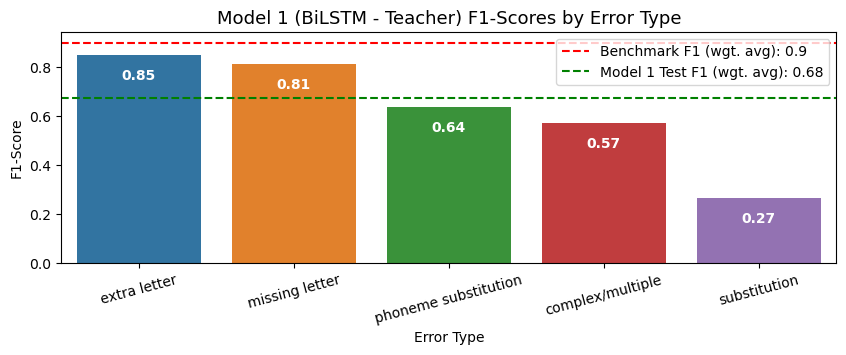

In [58]:
# f1-scores as bar plot

plt.figure(figsize=(10,3))

sns.barplot(x='Class / Metric', y='F1-Score', data=m1_metrics.iloc[:-3,:].sort_values(by='F1-Score', ascending=False), hue='Class / Metric')
# add hline for weighted avg f1-score
knn_benchmark = 0.90
plt.axhline(y=knn_benchmark, color='r', linestyle='--', label=f'Benchmark F1 (wgt. avg): {knn_benchmark}')
plt.axhline(y=m1_metrics.loc[m1_metrics['Class / Metric'] == 'weighted avg', 'F1-Score'].values[0], color='g', linestyle='--', label=f'Model 1 Test F1 (wgt. avg): {round(m1_metrics.loc[m1_metrics["Class / Metric"] == "weighted avg", "F1-Score"].values[0], 2)}')


# add f1-scores for each class as text above the bars
for i, v in enumerate(m1_metrics.iloc[:-3,:].sort_values(by='F1-Score', ascending=False)['F1-Score']):
    plt.text(i, v - 0.1, str(round(v, 2)), color='white', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=15)
plt.xlabel('Error Type')
plt.ylabel('F1-Score')
plt.title('Model 1 (BiLSTM - Teacher) F1-Scores by Error Type', fontsize=13)
plt.legend()
plt.show()


In [4]:
m2_metrics.head()

,Epoch,Train_MSE,Val_MSE,Val_Cosine_Similarity
0,1,0.900731,0.693090,0.791943
1,2,0.703939,0.680496,0.793561
2,3,0.685288,0.664914,0.798969
3,4,0.671905,0.653784,0.802145
4,5,0.641424,0.631707,0.808698


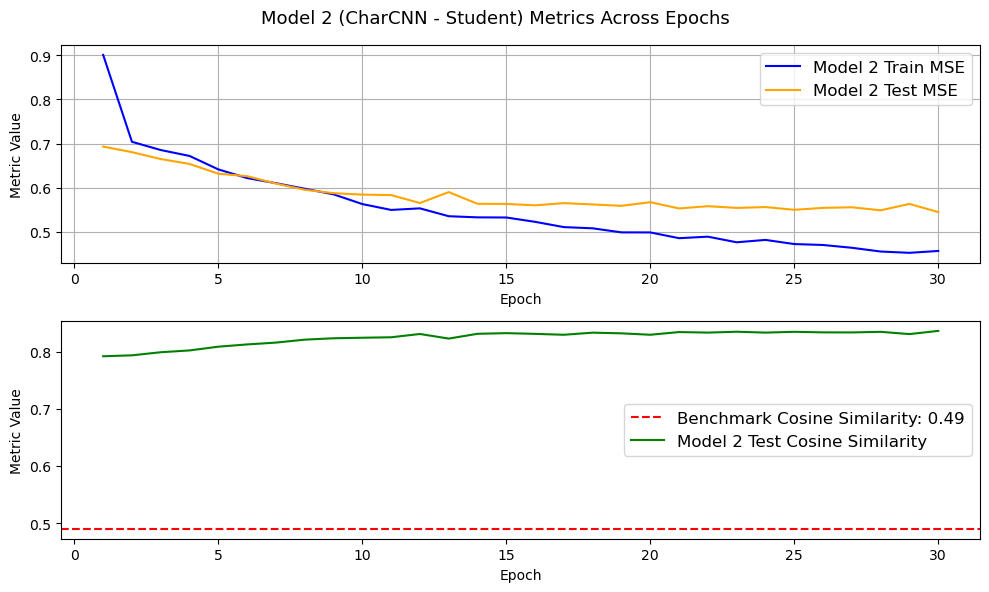

In [60]:
# plot m2_metrics across epochs

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
sns.lineplot(x='Epoch', y='Train_MSE', data=m2_metrics, label='Model 2 Train MSE', color='blue')
sns.lineplot(x='Epoch', y='Val_MSE', data=m2_metrics, label='Model 2 Test MSE', color='orange')
plt.xlabel('Epoch')
plt.grid()
plt.legend(fontsize=12)
plt.ylabel('Metric Value')

plt.subplot(2, 1, 2)
cosine_bench = 0.49
plt.axhline(y=cosine_bench, color='r', linestyle='--', label=f'Benchmark Cosine Similarity: {cosine_bench}')
sns.lineplot(x='Epoch', y='Val_Cosine_Similarity', data=m2_metrics, label='Model 2 Test Cosine Similarity', color='green')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.legend(fontsize=12)

plt.suptitle('Model 2 (CharCNN - Student) Metrics Across Epochs', fontsize=13)
plt.tight_layout()
plt.show()